# 02 — Data Preprocessing
## SMNA2026 Assignment 2: Public Sentiment Toward Electric Vehicles in Australia

**Team:** Ansh Anand Parekh (s4060237), Disha Dogra (s4091900), Syna Arora (s4109652)

### What this notebook does:
1. Loads raw posts and comments from CSV
2. Removes deleted posts, bots, and low quality content
3. Cleans text for NLP analysis
4. Anonymises usernames for privacy compliance
5. Adds useful features (year, month, text length)
6. Saves cleaned data ready for network and NLP analysis

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import re
import os
import hashlib
import matplotlib.pyplot as plt
from datetime import datetime

# Directories
RAW_DIR       = '../data/raw/'
PROCESSED_DIR = '../data/processed/'
FIGURES_DIR   = '../reports/figures/'

for d in [PROCESSED_DIR, FIGURES_DIR]:
    os.makedirs(d, exist_ok=True)

print('Libraries imported!')

Libraries imported!


## 2. Load Raw Data

In [2]:
# Load raw data
posts_df    = pd.read_csv(os.path.join(RAW_DIR, 'posts.csv'))
comments_df = pd.read_csv(os.path.join(RAW_DIR, 'comments.csv'))

print(f'Raw posts loaded    : {len(posts_df)}')
print(f'Raw comments loaded : {len(comments_df)}')
print(f'\nPosts columns:')
print(list(posts_df.columns))
print(f'\nComments columns:')
print(list(comments_df.columns))
print(f'\nPosts by subreddit (raw):')
print(posts_df['subreddit'].value_counts())

Raw posts loaded    : 311
Raw comments loaded : 94768

Posts columns:
['post_id', 'title', 'selftext', 'score', 'upvote_ratio', 'num_comments', 'author', 'created_utc', 'created_dt', 'subreddit', 'url', 'permalink']

Comments columns:
['comment_id', 'post_id', 'parent_id', 'is_toplevel', 'author', 'body', 'score', 'created_utc', 'created_dt', 'subreddit', 'depth']

Posts by subreddit (raw):
subreddit
electricvehicles    300
AusFinance            9
australia             2
Name: count, dtype: int64


## 3. Helper Functions

In [3]:
def clean_text(text):
    """
    Clean Reddit text for NLP analysis.
    Removes URLs, markdown, special characters.
    """
    if not isinstance(text, str) or not text.strip():
        return ''
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    # Remove Reddit markdown
    text = re.sub(r'\*\*|__|~~|`|\^|&gt;|&lt;|&amp;', '', text)
    # Remove special characters but keep apostrophes and hyphens
    text = re.sub(r'[^a-zA-Z0-9\s\'\-]', ' ', text)
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text


def anonymise_user(username):
    """
    Anonymise username using MD5 hash for privacy compliance.
    Deleted/removed users stay as 'anonymous'.
    """
    deleted = ['[deleted]', '[removed]', 'AutoModerator',
               'None', 'nan', '']
    if not isinstance(username, str) or username in deleted:
        return 'anonymous'
    return 'user_' + hashlib.md5(username.encode()).hexdigest()[:8]


def word_count(text):
    """Count words in text."""
    if not isinstance(text, str):
        return 0
    return len(text.split())


print('Helper functions ready!')

Helper functions ready!


## 4. Clean Posts

In [4]:
print('Cleaning posts...')
print('=' * 50)

df     = posts_df.copy()
before = len(df)

# ── Step 1: Drop missing critical fields ──
df = df.dropna(subset=['post_id', 'title', 'created_utc'])
print(f'After dropping missing fields : {len(df)} (removed {before - len(df)})')

# ── Step 2: Remove deleted posts ──
before = len(df)
deleted_titles = ['[deleted]', '[removed]', '']
df = df[~df['title'].isin(deleted_titles)]
df = df[df['title'].notna()]
print(f'After removing deleted posts  : {len(df)} (removed {before - len(df)})')

# ── Step 3: Remove duplicates ──
before = len(df)
df = df.drop_duplicates(subset='post_id')
print(f'After removing duplicates     : {len(df)} (removed {before - len(df)})')

# ── Step 4: Clean text fields ──
df['title_clean']    = df['title'].apply(clean_text)
df['selftext_clean'] = df['selftext'].fillna('').apply(clean_text)
df['full_text']      = (df['title_clean'] + ' ' + df['selftext_clean']).str.strip()

# ── Step 5: Anonymise authors ──
df['author_anon'] = df['author'].apply(anonymise_user)

# ── Step 6: Parse dates ──
df['created_dt'] = pd.to_datetime(df['created_dt'], errors='coerce')
df['year']       = df['created_dt'].dt.year
df['month']      = df['created_dt'].dt.month
df['year_month'] = df['created_dt'].dt.to_period('M').astype(str)
df['day_of_week']= df['created_dt'].dt.day_name()

# ── Step 7: Add text features ──
df['title_word_count']    = df['title_clean'].apply(word_count)
df['selftext_word_count'] = df['selftext_clean'].apply(word_count)

# ── Step 8: Remove very short titles ──
before = len(df)
df = df[df['title_word_count'] >= 3]
print(f'After removing short titles   : {len(df)} (removed {before - len(df)})')

# ── Step 9: Remove rows with invalid dates ──
before = len(df)
df = df.dropna(subset=['created_dt'])
print(f'After removing invalid dates  : {len(df)} (removed {before - len(df)})')

posts_clean = df.reset_index(drop=True)

print(f'\nFINAL CLEAN POSTS: {len(posts_clean)}')
print(f'\nBy subreddit:')
print(posts_clean['subreddit'].value_counts())

Cleaning posts...
After dropping missing fields : 311 (removed 0)
After removing deleted posts  : 311 (removed 0)
After removing duplicates     : 311 (removed 0)
After removing short titles   : 311 (removed 0)
After removing invalid dates  : 311 (removed 0)

FINAL CLEAN POSTS: 311

By subreddit:
subreddit
electricvehicles    300
AusFinance            9
australia             2
Name: count, dtype: int64


## 5. Clean Comments

In [5]:
print('Cleaning comments...')
print('=' * 50)

dc     = comments_df.copy()
before = len(dc)

# ── Step 1: Drop missing fields ──
dc = dc.dropna(subset=['comment_id', 'post_id', 'body'])
print(f'After dropping missing fields : {len(dc)} (removed {before - len(dc)})')

# ── Step 2: Remove bots and deleted accounts ──
before = len(dc)
BOT_LIST = [
    'AutoModerator', '[deleted]', '[removed]',
    'BotDefense', 'RepostSleuthBot', 'RemindMeBot',
    'B0tRank', 'sneakpeek_bot', 'WikiTextBot',
    'TotesMessenger', 'converter-bot'
]
dc = dc[~dc['author'].isin(BOT_LIST)]
print(f'After removing bots           : {len(dc)} (removed {before - len(dc)})')

# ── Step 3: Remove deleted comment bodies ──
before = len(dc)
dc = dc[~dc['body'].isin(['[deleted]', '[removed]'])]
dc = dc[dc['body'].notna()]
print(f'After removing deleted bodies : {len(dc)} (removed {before - len(dc)})')

# ── Step 4: Remove duplicates ──
before = len(dc)
dc = dc.drop_duplicates(subset='comment_id')
print(f'After removing duplicates     : {len(dc)} (removed {before - len(dc)})')

# ── Step 5: Clean text ──
dc['body_clean'] = dc['body'].apply(clean_text)

# ── Step 6: Anonymise authors ──
dc['author_anon'] = dc['author'].apply(anonymise_user)

# ── Step 7: Parse dates ──
dc['created_dt'] = pd.to_datetime(dc['created_dt'], errors='coerce')
dc['year']       = dc['created_dt'].dt.year
dc['month']      = dc['created_dt'].dt.month
dc['year_month'] = dc['created_dt'].dt.to_period('M').astype(str)

# ── Step 8: Add word count ──
dc['body_word_count'] = dc['body_clean'].apply(word_count)

# ── Step 9: Remove very short comments ──
before = len(dc)
dc = dc[dc['body_word_count'] >= 3]
print(f'After removing short comments : {len(dc)} (removed {before - len(dc)})')

# ── Step 10: Only keep comments for our collected posts ──
before        = len(dc)
valid_post_ids = set(posts_clean['post_id'])
dc = dc[dc['post_id'].isin(valid_post_ids)]
print(f'After matching to posts       : {len(dc)} (removed {before - len(dc)})')

comments_clean = dc.reset_index(drop=True)

print(f'\nFINAL CLEAN COMMENTS: {len(comments_clean)}')
print(f'Unique posts with comments : {comments_clean["post_id"].nunique()}')
print(f'Unique authors             : {comments_clean["author"].nunique()}')
print(f'Avg comments per post      : {len(comments_clean)/max(comments_clean["post_id"].nunique(),1):.1f}')

Cleaning comments...
After dropping missing fields : 94767 (removed 1)
After removing bots           : 86797 (removed 7970)
After removing deleted bodies : 86797 (removed 0)
After removing duplicates     : 86797 (removed 0)
After removing short comments : 84281 (removed 2516)
After matching to posts       : 84281 (removed 0)

FINAL CLEAN COMMENTS: 84281
Unique posts with comments : 309
Unique authors             : 23561
Avg comments per post      : 272.8


## 6. Quality Check

In [6]:
print('=' * 60)
print('QUALITY CHECK')
print('=' * 60)

print(f'\nPOSTS')
print(f'  Raw posts         : {len(posts_df)}')
print(f'  Clean posts       : {len(posts_clean)}')
print(f'  Retention rate    : {len(posts_clean)/max(len(posts_df),1)*100:.1f}%')
print(f'  Date range        : {posts_clean["created_dt"].min().date()} to {posts_clean["created_dt"].max().date()}')
print(f'  Avg score         : {posts_clean["score"].mean():.1f}')
print(f'  Avg title length  : {posts_clean["title_word_count"].mean():.1f} words')
print(f'  Subreddits        :')
print(posts_clean['subreddit'].value_counts().to_string())

print(f'\nCOMMENTS')
print(f'  Raw comments      : {len(comments_df)}')
print(f'  Clean comments    : {len(comments_clean)}')
print(f'  Retention rate    : {len(comments_clean)/max(len(comments_df),1)*100:.1f}%')
print(f'  Top level         : {comments_clean["is_toplevel"].sum()}')
print(f'  Replies           : {(~comments_clean["is_toplevel"]).sum()}')
print(f'  Avg body length   : {comments_clean["body_word_count"].mean():.1f} words')
print(f'  Avg per post      : {len(comments_clean)/max(comments_clean["post_id"].nunique(),1):.1f}')

print(f'\nMissing values in posts:')
print(posts_clean[['post_id','title_clean','author_anon','created_dt']].isnull().sum())
print(f'\nMissing values in comments:')
print(comments_clean[['comment_id','post_id','body_clean','author_anon']].isnull().sum())

QUALITY CHECK

POSTS
  Raw posts         : 311
  Clean posts       : 311
  Retention rate    : 100.0%
  Date range        : 2023-03-23 to 2025-12-30
  Avg score         : 1583.9
  Avg title length  : 13.5 words
  Subreddits        :
subreddit
electricvehicles    300
AusFinance            9
australia             2

COMMENTS
  Raw comments      : 94768
  Clean comments    : 84281
  Retention rate    : 88.9%
  Top level         : 21838
  Replies           : 62443
  Avg body length   : 40.9 words
  Avg per post      : 272.8

Missing values in posts:
post_id        0
title_clean    0
author_anon    0
created_dt     0
dtype: int64

Missing values in comments:
comment_id     0
post_id        0
body_clean     0
author_anon    0
dtype: int64


## 7. Visualise Cleaned Data

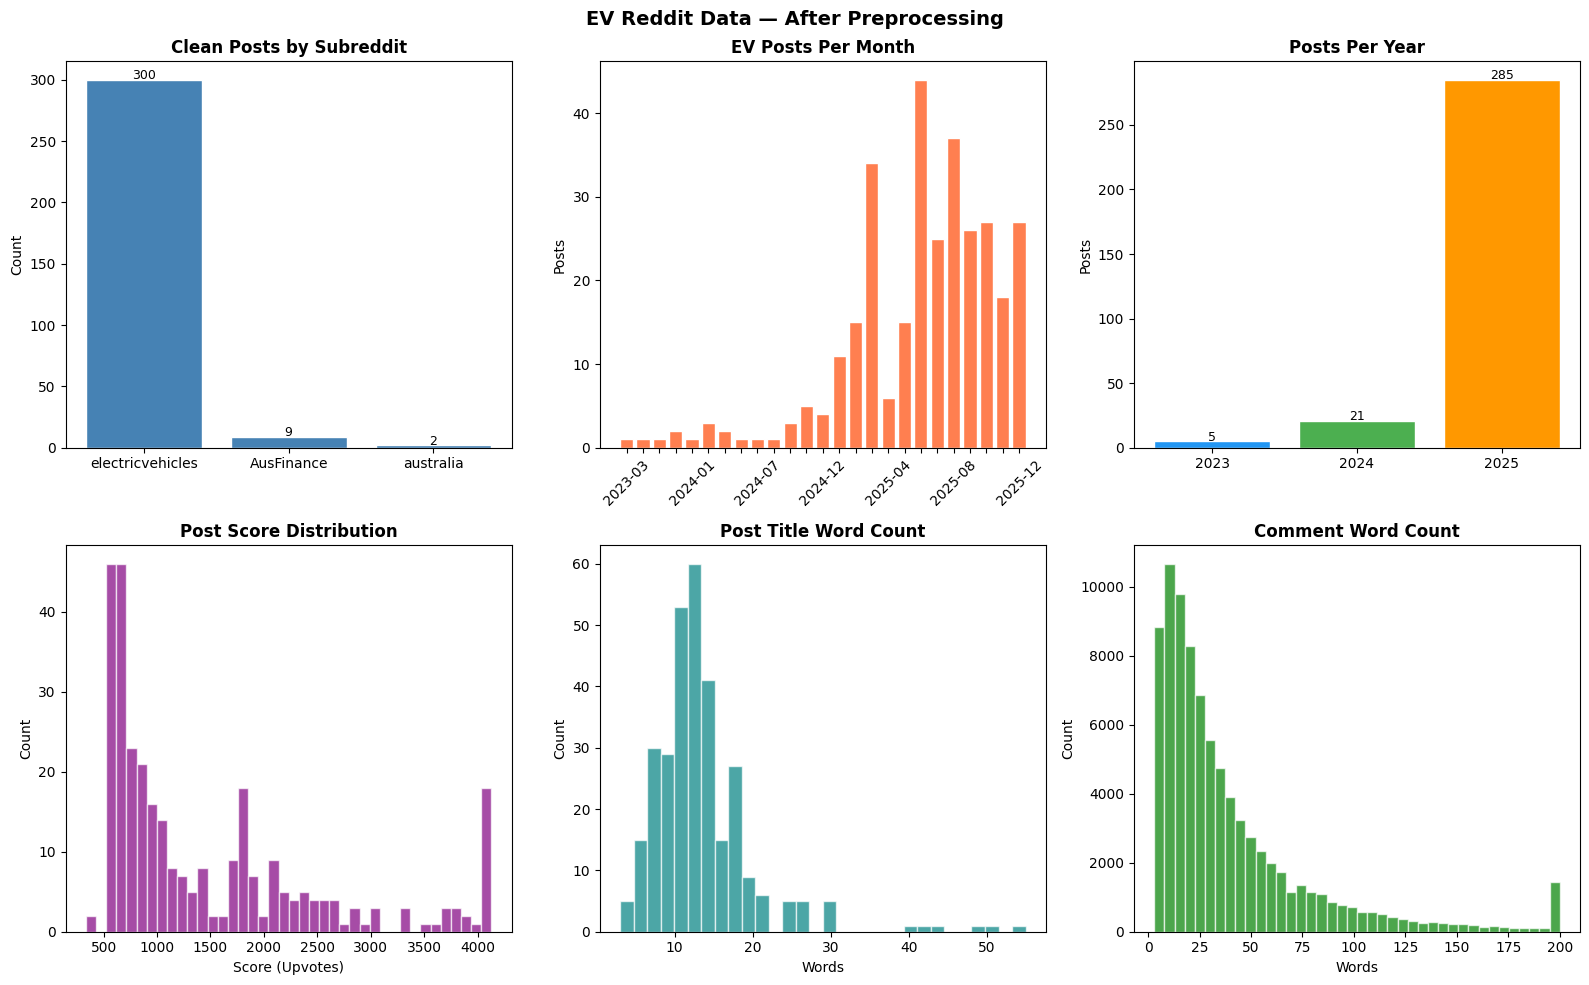

Figure saved!


In [7]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Plot 1: Posts by subreddit
sc = posts_clean['subreddit'].value_counts()
axes[0,0].bar(sc.index, sc.values, color='steelblue', edgecolor='white')
axes[0,0].set_title('Clean Posts by Subreddit', fontweight='bold')
axes[0,0].set_ylabel('Count')
for i, v in enumerate(sc.values):
    axes[0,0].text(i, v+0.5, str(v), ha='center', fontsize=9)

# Plot 2: Posts over time
monthly = posts_clean.groupby('year_month').size().reset_index(name='count')
axes[0,1].bar(monthly['year_month'], monthly['count'], color='coral', edgecolor='white')
axes[0,1].set_title('EV Posts Per Month', fontweight='bold')
axes[0,1].set_ylabel('Posts')
axes[0,1].tick_params(axis='x', rotation=45)
for i, label in enumerate(axes[0,1].get_xticklabels()):
    if i % 4 != 0: label.set_visible(False)

# Plot 3: Posts per year
yearly = posts_clean.groupby('year').size().reset_index(name='count')
axes[0,2].bar(yearly['year'].astype(str), yearly['count'],
              color=['#2196F3','#4CAF50','#FF9800'], edgecolor='white')
axes[0,2].set_title('Posts Per Year', fontweight='bold')
axes[0,2].set_ylabel('Posts')
for i, v in enumerate(yearly['count']):
    axes[0,2].text(i, v+0.5, str(v), ha='center', fontsize=9)

# Plot 4: Score distribution
axes[1,0].hist(
    posts_clean['score'].clip(upper=posts_clean['score'].quantile(0.95)),
    bins=40, color='purple', alpha=0.7, edgecolor='white'
)
axes[1,0].set_title('Post Score Distribution', fontweight='bold')
axes[1,0].set_xlabel('Score (Upvotes)')
axes[1,0].set_ylabel('Count')

# Plot 5: Title word count
axes[1,1].hist(posts_clean['title_word_count'], bins=30,
               color='teal', alpha=0.7, edgecolor='white')
axes[1,1].set_title('Post Title Word Count', fontweight='bold')
axes[1,1].set_xlabel('Words')
axes[1,1].set_ylabel('Count')

# Plot 6: Comment word count
axes[1,2].hist(
    comments_clean['body_word_count'].clip(upper=200),
    bins=40, color='green', alpha=0.7, edgecolor='white'
)
axes[1,2].set_title('Comment Word Count', fontweight='bold')
axes[1,2].set_xlabel('Words')
axes[1,2].set_ylabel('Count')

plt.suptitle('EV Reddit Data — After Preprocessing', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'preprocessing_overview.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved!')

## 8. Save Processed Data

In [8]:
# Save cleaned posts
posts_out    = os.path.join(PROCESSED_DIR, 'posts_clean.csv')
comments_out = os.path.join(PROCESSED_DIR, 'comments_clean.csv')

posts_clean.to_csv(posts_out, index=False)
comments_clean.to_csv(comments_out, index=False)

print('Files saved:')
print(f'  posts_clean.csv    : {os.path.getsize(posts_out)/1024:.1f} KB')
print(f'  comments_clean.csv : {os.path.getsize(comments_out)/1024:.1f} KB')
print(f'\nReady for:')
print(f'  03_network_analysis.ipynb')
print(f'  04_nlp_sentiment.ipynb')

Files saved:
  posts_clean.csv    : 527.1 KB
  comments_clean.csv : 47609.2 KB

Ready for:
  03_network_analysis.ipynb
  04_nlp_sentiment.ipynb


## 9. Final Summary

In [9]:
print('=' * 60)
print('PREPROCESSING COMPLETE')
print('=' * 60)
print(f'Posts  : {len(posts_df)} raw -> {len(posts_clean)} clean')
print(f'Comments: {len(comments_df)} raw -> {len(comments_clean)} clean')
print(f'\nData ready for analysis:')
print(f'  Subreddits : {", ".join(["r/"+s for s in posts_clean["subreddit"].unique()])}')
print(f'  Date range : {posts_clean["created_dt"].min().date()} to {posts_clean["created_dt"].max().date()}')
print(f'  Posts      : {len(posts_clean)}')
print(f'  Comments   : {len(comments_clean)}')
print(f'  Users      : {comments_clean["author"].nunique()}')
print(f'\nFiles saved:')
print(f'  data/processed/posts_clean.csv')
print(f'  data/processed/comments_clean.csv')
print(f'  reports/figures/preprocessing_overview.png')
print('=' * 60)

PREPROCESSING COMPLETE
Posts  : 311 raw -> 311 clean
Comments: 94768 raw -> 84281 clean

Data ready for analysis:
  Subreddits : r/australia, r/AusFinance, r/electricvehicles
  Date range : 2023-03-23 to 2025-12-30
  Posts      : 311
  Comments   : 84281
  Users      : 23561

Files saved:
  data/processed/posts_clean.csv
  data/processed/comments_clean.csv
  reports/figures/preprocessing_overview.png
